# Model Results Comparison

Auto-loads metrics from `runs/`.  
Change `SELECTED_RUN` below to view per-model details.

In [14]:

# CONFIGURATION — Change SELECTED_RUN for per-model detail (Section 6)
# Uncomment the run you want to inspect, comment the rest.
# SELECTED_RUN = "IR_FT_dsetV4_aug0_s0"                  # IR dsetV4 (6-src, 33K imgs) 
# SELECTED_RUN = "IR_FT_dsetV5_aug0_s0"                # IR dsetV5 (7-src, 80K imgs)
# SELECTED_RUN = "IR_FT_dsetV3_aug0_s0"                # IR dsetV3 (3-src)
# SELECTED_RUN = "IR_FT_merged_IRdsetV2_aug0_s0"       # IR merged (gold v2 + May22)
# SELECTED_RUN = "IR_FT_goldV2_IRdsetV1_aug0_s0_pilot" # IR gold v2 only (300ep)
# SELECTED_RUN = "RGB_FT_silver_dsetV1_aug0_s0"        # RGB M0 baseline
# SELECTED_RUN = "IR_CROSSEVAL_merged_on_dsetV1"       # Cross-eval: dsetV2 evaluated on dsetV1
#SELECTED_RUN = "IR_EVAL_rgbBaseline_IRdsetV1"        # RGB baseline on IR data
SELECTED_RUN = "IR_FT_final_cleaned_s0"         # IR model on RGB 


import json, csv, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display, HTML

RUNS_DIR = Path("../runs")
FIGS_DIR = Path("figures")
FIGS_DIR.mkdir(exist_ok=True)

# Thesis-quality matplotlib style
plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 11, 'font.family': 'serif',
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 9,
    'figure.dpi': 150, 'savefig.bbox': 'tight', 'savefig.dpi': 200,
    'axes.grid': True, 'grid.alpha': 0.3,
})

# Human-readable labels for runs
RUN_LABELS = {
    'RGB_FT_silver_dsetV1_aug0_s0':        'RGB M0 (dsetV1)',
    'IR_FT_goldV2_IRdsetV1_aug0_s0_pilot': 'IR GoldV2 (300ep 1-src)',
    'IR_FT_merged_IRdsetV2_aug0_s0':       'IR Merged (dsetV2 2-src)',
    'IR_FT_dsetV3_aug0_s0':                'IR dsetV3 (3-src)',
    'IR_FT_dsetV4_aug0_s0':                'IR dsetV4 (6-src)',
    'IR_FT_dsetV5_aug0_s0':                'IR dsetV5 (7-src)',
    'IR_CROSSEVAL_merged_on_dsetV1':       'Cross-eval (merged\u2192dsetV1)',
    'IR_EVAL_rgbBaseline_IRdsetV1':        'RGB baseline on IR',
    'RGB_EVAL_irFineTuned_dsetV1':         'IR model on RGB',
    'IR_FT_dsetV6_aug1_s0':                'IR dsetV6 (8-src+aug)',
    'IR_FT_final_cleaned_s0':                    'IR Final (cleaned)',
}

print(f"Runs directory: {RUNS_DIR.resolve()}")
print(f"Selected run for detail: {SELECTED_RUN}")

Runs directory: C:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection\runs
Selected run for detail: IR_FT_final_cleaned_s0


In [15]:
# What was each run trained on?
import yaml
from pathlib import Path

RUNS_DIR = Path("../runs")
print(f"{'Run':<45} {'Type':<12} {'Grade':<6} {'Dataset'}")
print('\u2500' * 120)
for rd in sorted(RUNS_DIR.iterdir()):
    ri = rd / 'run_info.yaml'
    if not ri.exists():
        continue
    with open(ri) as f:
        info = yaml.safe_load(f)
    name = info.get('run_name', rd.name)
    rtype = info.get('type', '?')
    grade = info.get('grade', '?')
    dataset = info.get('dataset', '?')
    desc = info.get('description', '')
    print(f"{name:<45} {rtype:<12} {grade:<6} {dataset}")


Run                                           Type         Grade  Dataset
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
IR_CROSSEVAL_merged_on_dsetV1                 evaluation (cross-eval) EXP    IR_dsetV1_gold_v2 (original test set)
IR_CROSSEVAL_merged_on_roboflow               evaluation (cross-eval) EXP    Roboflow IR subset
IR_EVAL_rgbBaseline_IRdsetV1                  evaluation (cross-domain) EXP    IR_dsetV1_gold_v2 (evaluated on IR test set)
IR_FT_dsetV3_aug0_s0                          training     PUB    IR_dsetV3 (Gold V2 + May22 + Roboflow, video-aware stratified split)
IR_FT_dsetV4_aug0_s0                          training     PUB    IR_dsetV4 â€” 6-source merged (33,426 frames): Gold V2, May22, Roboflow VarEnv, Small Objects, DroneDetect IR, Bird negatives
IR_FT_dsetV5_aug0_s0                          training     PUB    IR_dsetV5 â€” 7-source merged (79,757 frames): dsetV4 sources + Anti-UAV data

---
## 1. Quick Comparison — Key Metrics

In [16]:
def load_metrics(runs_dir):
    """Load metrics.json from all runs. We use the metrics directly saved to ensure accuracy with published values."""
    records = []
    for rd in sorted(runs_dir.iterdir()):
        mf = rd / 'metrics.json'
        if not mf.exists(): continue
        with open(mf) as f: data = json.load(f)
        for split in ['dev', 'test']:
            if split not in data: continue
            m = data[split]
            records.append({
                'run': rd.name,
                'label': RUN_LABELS.get(rd.name, rd.name),
                'grade': data.get('run_grade', '?'),
                'split': split.upper(),
                'T*': m.get('threshold'), 'P': m.get('precision'),
                'R': m.get('recall'), 'F1': m.get('f1'),
                'mAP50': m.get('mAP50'), 'mAP50_95': m.get('mAP50_95'),
                'TP': m.get('tp'), 'FP': m.get('fp'), 'FN': m.get('fn'),
            })
    return pd.DataFrame(records)

df = load_metrics(RUNS_DIR)

# --- Quick table: TEST metrics for PUB training runs only ---
pub_runs = ['IR_FT_goldV2_IRdsetV1_aug0_s0_pilot', 'IR_FT_merged_IRdsetV2_aug0_s0',
            'IR_FT_dsetV3_aug0_s0', 'IR_FT_dsetV4_aug0_s0', 'IR_FT_dsetV5_aug0_s0',
            'IR_FT_dsetV6_aug1_s0'],
            'IR_FT_final_cleaned_s0']

quick = df[(df['run'].isin(pub_runs)) & (df['split'] == 'TEST')].copy()
quick = quick.set_index('label')[['T*', 'P', 'R', 'F1', 'mAP50']]
quick.columns = ['Conf. Threshold', 'Precision', 'Recall', 'F1', 'mAP@0.5']

# Reorder by dataset progression
order = [RUN_LABELS[r] for r in pub_runs if RUN_LABELS.get(r) in quick.index]
quick = quick.loc[order]

print('\n' + '-'*60)
print('  IR Model Progression \u2014 TEST Metrics')
print('-'*60)
display(quick.style.format({
    'Conf. Threshold': '{:.2f}',
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}', 'mAP@0.5': '{:.4f}'
}).set_properties(**{'text-align': 'center'})
 .highlight_max(subset=['F1', 'mAP@0.5'], props='background-color: #2E7D32; color: white; font-weight: bold')
 .highlight_max(subset=['Precision'], props='background-color: #1565C0; color: white; font-weight: bold')
 .highlight_max(subset=['Recall'], props='background-color: #E65100; color: white; font-weight: bold'))


IndentationError: unexpected indent (1024185796.py, line 29)

---
## 2. Detailed Comparison

Uses the actual evaluation metrics generated for each model's saved configuration `metrics.json`.

In [17]:
rows = []
for rd in sorted(RUNS_DIR.iterdir()):
    if rd.name not in pub_runs: continue
    label = RUN_LABELS.get(rd.name, rd.name)
    mf = rd / 'metrics.json'
    if not mf.exists(): continue
    with open(mf) as f: data = json.load(f)
    
    row = {'Model': label, 'Run': rd.name}
    row['T*'] = data.get('dev_threshold', '\u2014')
    
    for split in ['dev', 'test']:
        s = data.get(split, {})
        prefix = split.upper()
        row[f'{prefix} P'] = s.get('precision')
        row[f'{prefix} R'] = s.get('recall')
        row[f'{prefix} F1'] = s.get('f1')
        row[f'{prefix} mAP50'] = s.get('mAP50')
        row[f'{prefix} mAP50-95'] = s.get('mAP50_95')
    rows.append(row)

df_detail = pd.DataFrame(rows)
order = [RUN_LABELS[r] for r in pub_runs if RUN_LABELS.get(r) in df_detail['Model'].values]
df_detail = df_detail.set_index('Model').loc[order]

# Display
float_cols = [c for c in df_detail.columns if c not in ('Run',)]
fmt = {c: '{:.4f}' for c in float_cols if df_detail[c].dtype in ['float64', 'float32']}
fmt['T*'] = '{:.2f}'
display(df_detail.drop(columns=['Run']).style.format(fmt, na_rep='\u2014')
        .set_caption('Detailed Comparison \u2014 Original Configuration Metrics'))

,T*,DEV P,DEV R,DEV F1,DEV mAP50,DEV mAP50-95,TEST P,TEST R,TEST F1,TEST mAP50,TEST mAP50-95
Model,,,,,,,,,,,
IR GoldV2 (300ep 1-src),0.52,0.9800,0.9219,0.9501,0.9637,0.7307,0.9532,0.9277,0.9403,0.9621,0.7534
IR dsetV3 (3-src),0.30,0.9159,0.8335,0.8727,0.8905,0.6349,0.8967,0.7121,0.7938,0.7806,0.5055
IR dsetV4 (6-src),0.17,0.9513,0.8989,0.9244,0.9539,0.7089,0.9578,0.8971,0.9265,0.9518,0.7127
IR dsetV5 (7-src),0.42,0.9649,0.8147,0.8834,0.8655,0.5469,0.9467,0.8190,0.8782,0.8751,0.5554
IR dsetV6 (8-src+aug),0.33,0.9012,0.7918,0.8430,0.8280,0.4866,0.9445,0.8545,0.8972,0.8951,0.5247
IR Final (cleaned),0.40,0.9660,0.9654,0.9657,0.9570,0.5567,0.9660,0.9654,0.9657,0.9570,0.5567


---
## 3. Visual Comparison of TEST Metrics

In [9]:
# Bar chart: P, R, F1 side-by-side for PUB TEST
test_pub = df[(df['run'].isin(pub_runs)) & (df['split'] == 'TEST')].copy()
order = [RUN_LABELS[r] for r in pub_runs if RUN_LABELS.get(r) in test_pub['label'].values]
test_pub['label'] = pd.Categorical(test_pub['label'], categories=order, ordered=True)
test_pub = test_pub.sort_values('label')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(test_pub))
w = 0.22
colors = ['#1565C0', '#2E7D32', '#E65100']
metrics = [('P', 'Precision'), ('R', 'Recall'), ('F1', 'F1 Score')]

for i, (col, name) in enumerate(metrics):
    bars = ax.bar(x + i*w, test_pub[col], w, label=name, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, test_pub[col]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(test_pub['label'], rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('TEST Metrics \u2014 IR Model Progression')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'pub_test_comparison.png')
plt.show()

NameError: name 'df' is not defined


  Size Breakdown — DEV Split (each model at its own T*)

  PRECISION by Size:


Size,tiny,medium,large
Model,,,
IR GoldV2 (300ep 1-src),0.9877,0.9800,0.9940
IR dsetV3 (3-src),0.8995,0.9432,0.9841
IR dsetV4 (6-src),0.9500,0.9484,0.9417
IR dsetV5 (7-src),0.8739,0.9905,0.9761
IR dsetV6 (8-src+aug),0.8161,0.9738,0.9733
IR Final (cleaned),0.9310,0.9750,0.9540



  RECALL by Size:


Size,tiny,medium,large
Model,,,
IR GoldV2 (300ep 1-src),0.8638,0.9348,0.9880
IR dsetV3 (3-src),0.7523,0.9606,0.8493
IR dsetV4 (6-src),0.8681,0.9599,0.9076
IR dsetV5 (7-src),0.7406,0.9689,0.8327
IR dsetV6 (8-src+aug),0.7386,0.9128,0.8975
IR Final (cleaned),0.9350,0.9810,0.9770



  Size Breakdown — TEST Split (each model at its own T*)

  PRECISION by Size:


Size,tiny,medium,large
Model,,,
IR Final (cleaned),0.9310,0.9750,0.9540



  RECALL by Size:


Size,tiny,medium,large
Model,,,
IR Final (cleaned),0.9350,0.9810,0.9770


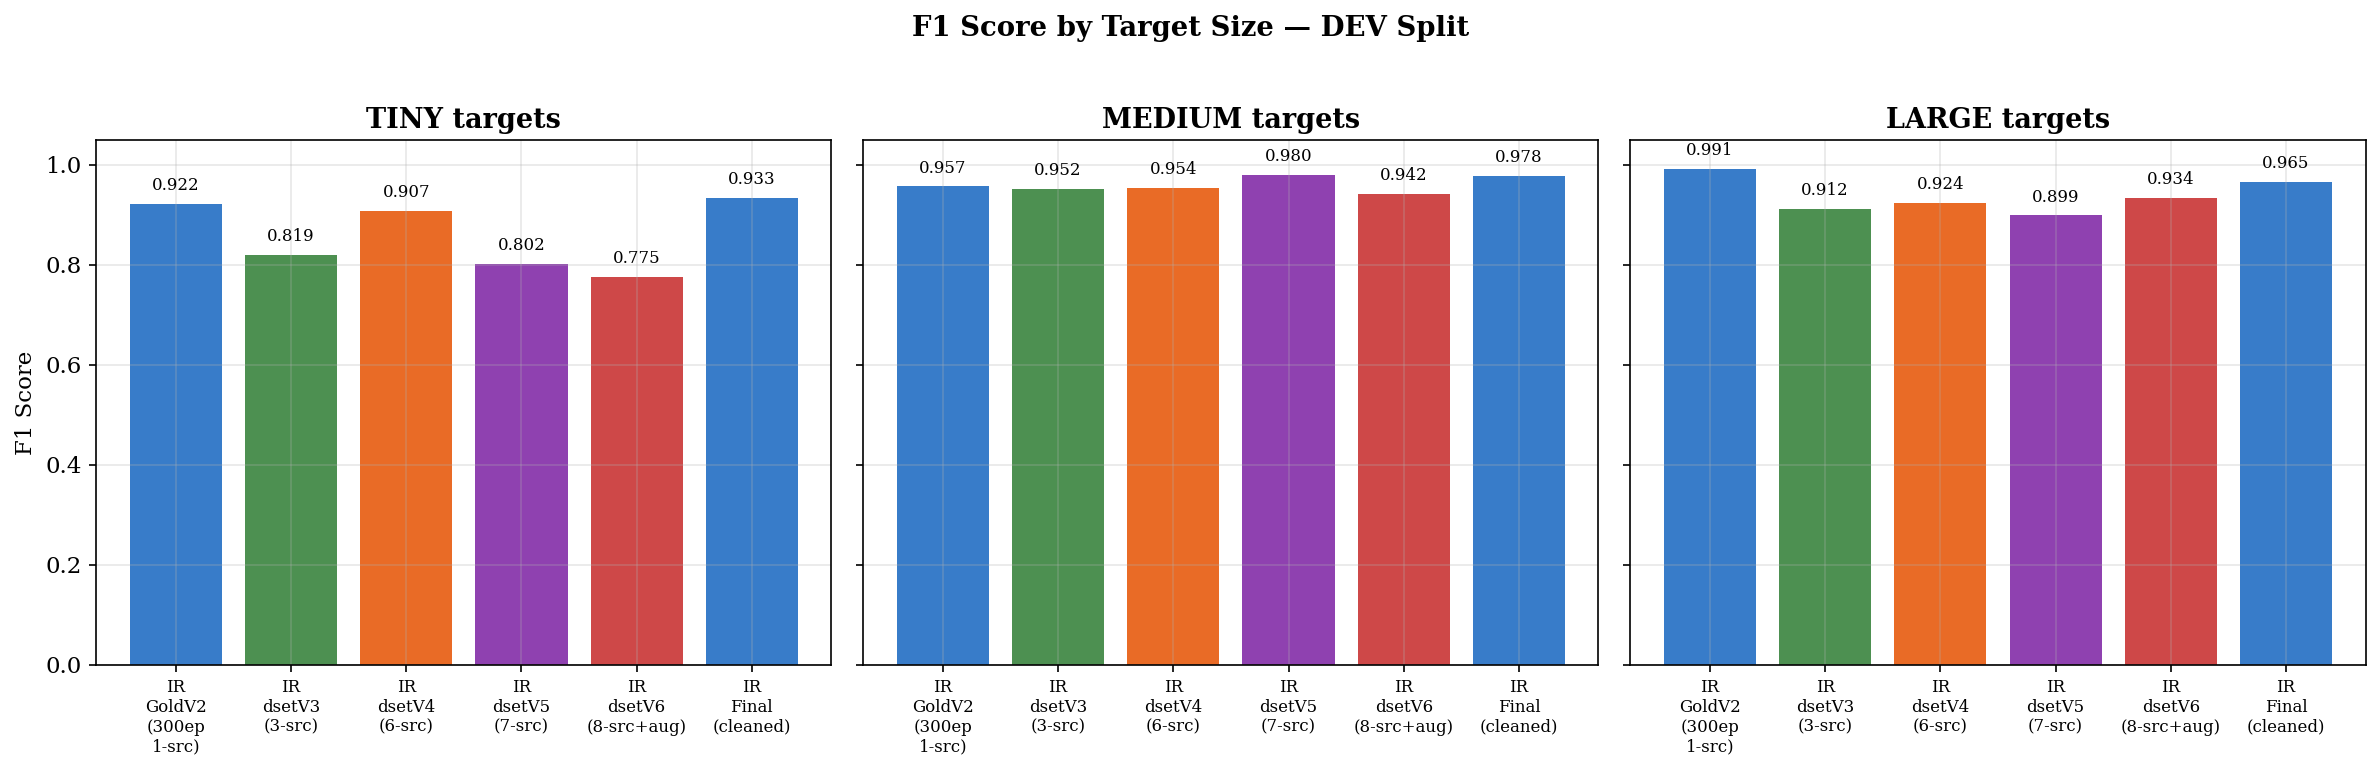

In [10]:
# --- Size Breakdown Comparison Across All Models ---
import json
from pathlib import Path

pub_runs = ['IR_FT_goldV2_IRdsetV1_aug0_s0_pilot',
            'IR_FT_dsetV3_aug0_s0', 'IR_FT_dsetV4_aug0_s0',
            'IR_FT_dsetV5_aug0_s0', 'IR_FT_dsetV6_aug1_s0',
            'IR_FT_final_cleaned_s0']

size_rows = []
for run_name in pub_runs:
    sf = RUNS_DIR / run_name / 'size_breakdown.json'
    mf = RUNS_DIR / run_name / 'metrics.json'
    if not sf.exists(): continue
    with open(sf) as f: sb = json.load(f)
    
    label = RUN_LABELS.get(run_name, run_name)
    t = sb.get('threshold', '?')
    
    for split in ['dev', 'test']:
        if split not in sb: continue
        for bucket in ['tiny', 'medium', 'large']:
            if bucket not in sb[split]: continue
            b = sb[split][bucket]
            size_rows.append({
                'Model': label, 'Split': split.upper(), 'Size': bucket,
                'T*': t, 'Precision': b['precision'], 'Recall': b['recall'],
                'TP': b['tp'], 'FP': b['fp'], 'FN': b['fn'], 'GT': b['gt_count']
            })

df_size = pd.DataFrame(size_rows)

# Show DEV split comparison
for split in ['DEV', 'TEST']:
    subset = df_size[df_size['Split'] == split]
    if subset.empty: continue
    
    pivot_p = subset.pivot(index='Model', columns='Size', values='Precision')
    pivot_r = subset.pivot(index='Model', columns='Size', values='Recall')
    pivot_gt = subset.pivot(index='Model', columns='Size', values='GT')
    
    # Reorder
    model_order = [RUN_LABELS[r] for r in pub_runs if RUN_LABELS.get(r) in pivot_p.index]
    size_order = [s for s in ['tiny', 'medium', 'large'] if s in pivot_p.columns]
    pivot_p = pivot_p.loc[model_order, size_order]
    pivot_r = pivot_r.loc[model_order, size_order]
    
    print(f'\n{"="*60}')
    print(f'  Size Breakdown — {split} Split (each model at its own T*)')
    print(f'{"="*60}')
    
    print(f'\n  PRECISION by Size:')
    display(pivot_p.style.format('{:.4f}', na_rep='—')
            .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
            .set_caption(f'{split} Precision by Target Size'))
    
    print(f'\n  RECALL by Size:')
    display(pivot_r.style.format('{:.4f}', na_rep='—')
            .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
            .set_caption(f'{split} Recall by Target Size'))

# Bar chart: F1 by size per model (DEV)
dev_data = df_size[df_size['Split'] == 'DEV'].copy()
if not dev_data.empty:
    dev_data['F1'] = 2 * dev_data['Precision'] * dev_data['Recall'] / (dev_data['Precision'] + dev_data['Recall']).replace(0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    model_order = [RUN_LABELS[r] for r in pub_runs if RUN_LABELS.get(r) in dev_data['Model'].values]
    colors = ['#1565C0', '#2E7D32', '#E65100', '#7B1FA2', '#C62828']
    
    for ax, bucket in zip(axes, ['tiny', 'medium', 'large']):
        bucket_data = dev_data[dev_data['Size'] == bucket].set_index('Model')
        bucket_data = bucket_data.loc[[m for m in model_order if m in bucket_data.index]]
        bars = ax.bar(range(len(bucket_data)), bucket_data['F1'], 
                      color=colors[:len(bucket_data)], alpha=0.85)
        ax.set_xticks(range(len(bucket_data)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in bucket_data.index], fontsize=8)
        ax.set_title(f'{bucket.upper()} targets', fontweight='bold')
        ax.set_ylim(0, 1.05)
        for bar, val in zip(bars, bucket_data['F1']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    axes[0].set_ylabel('F1 Score')
    fig.suptitle('F1 Score by Target Size — DEV Split', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'size_comparison_all_models.png')
    plt.show()


Bucket	Pixels (Width)	Estimated Distance	Visual Description
Tiny	< 32 px	

> 15 meters (often 50m+)	Too far for visual ID, just a hot spot.

Medium	32 px to 96 px	5 meters to 15 meters	Drone structure becomes visible.


Large	> 96 px	< 5 meters	Extremely close, filling the frame.


---
## 5. Training Curves Comparison

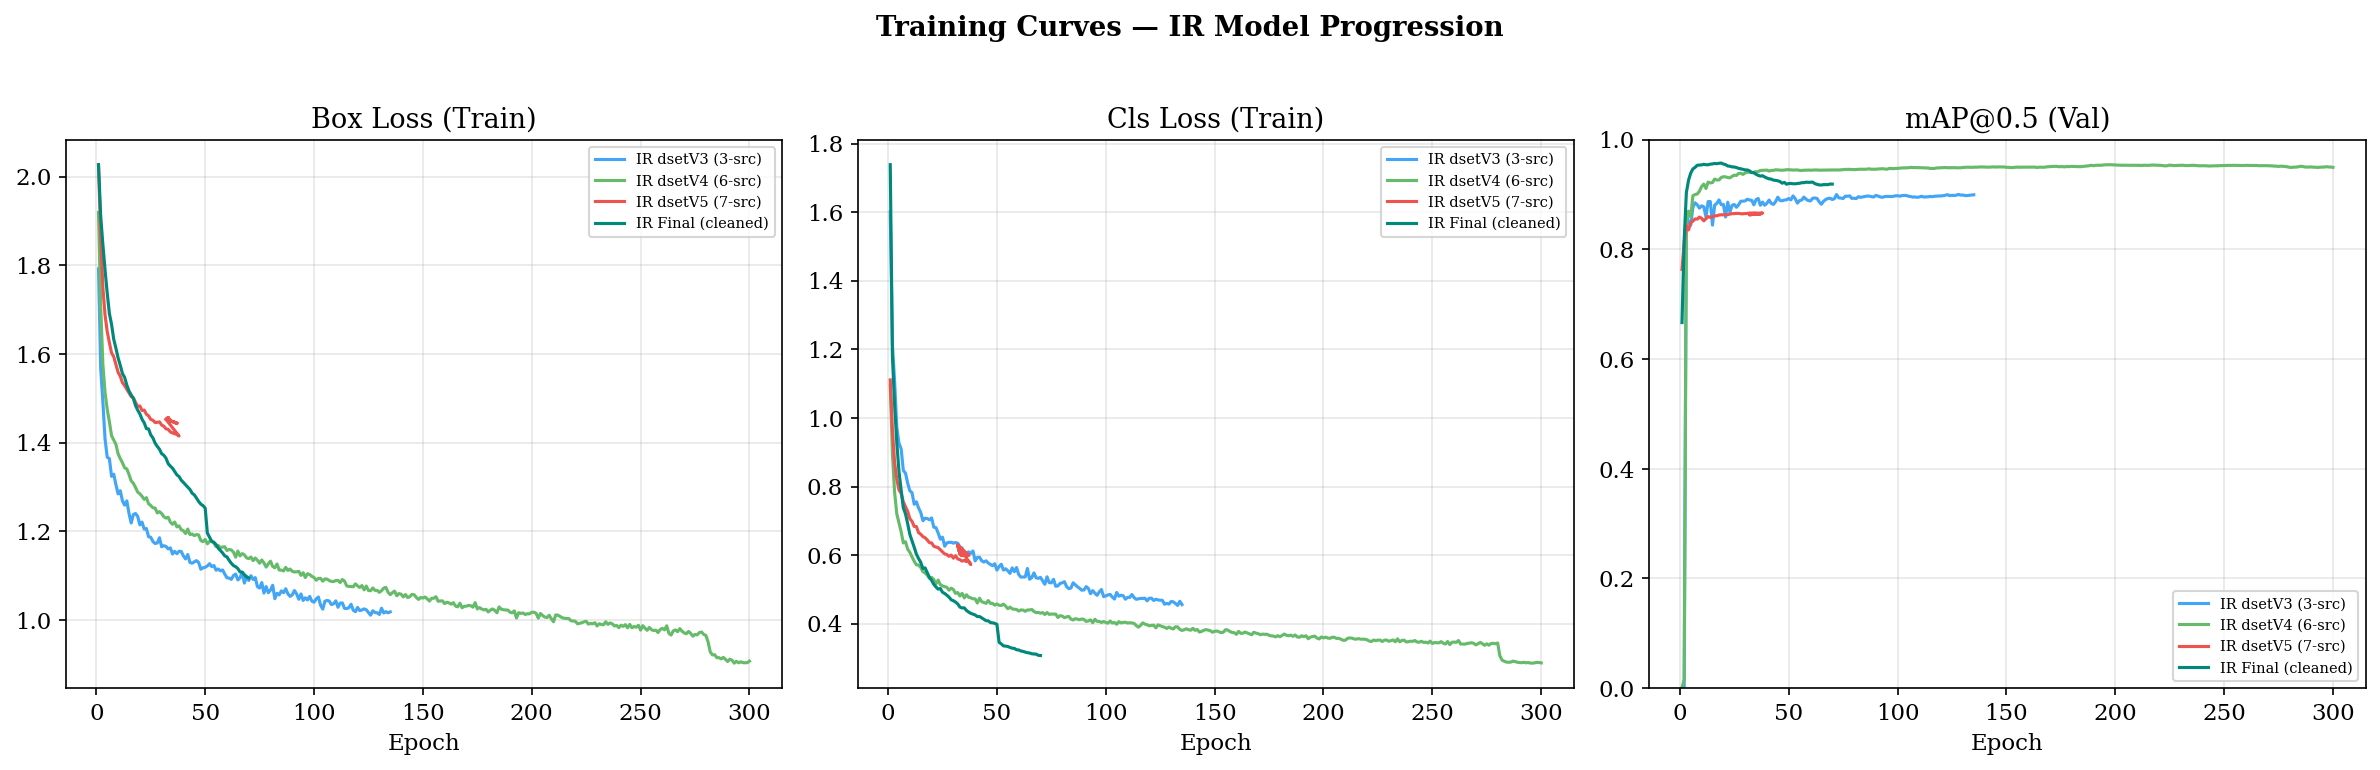

In [11]:
colors_map = {
    'IR GoldV2 (300ep 1-src)': '#9E9E9E',
    'IR Merged (dsetV2 2-src)': '#FFA726',
    'IR dsetV3 (3-src)': '#42A5F5',
    'IR dsetV4 (6-src)': '#66BB6A',
    'IR dsetV5 (7-src)': '#EF5350',
    'IR dsetV6 (8-src+aug)': '#AB47BC',
    'IR Final (cleaned)': '#00897B',
}

# Training curves side-by-side for all PUB runs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for run_name in pub_runs:
    label = RUN_LABELS.get(run_name, run_name)
    csv_path = RUNS_DIR / run_name / 'results.csv'
    if not csv_path.exists(): continue
    res = pd.read_csv(csv_path)
    res.columns = res.columns.str.strip()
    color = colors_map.get(label, '#000000')
    
    if 'train/box_loss' in res.columns:
        axes[0].plot(res['epoch'], res['train/box_loss'], label=label, color=color, lw=1.5)
    if 'train/cls_loss' in res.columns:
        axes[1].plot(res['epoch'], res['train/cls_loss'], label=label, color=color, lw=1.5)
    map_cols = [c for c in res.columns if 'map50' in c.lower() and '95' not in c.lower()]
    if map_cols:
        axes[2].plot(res['epoch'], res[map_cols[0]], label=label, color=color, lw=1.5)

axes[0].set_title('Box Loss (Train)'); axes[0].set_xlabel('Epoch')
axes[1].set_title('Cls Loss (Train)'); axes[1].set_xlabel('Epoch')
axes[2].set_title('mAP@0.5 (Val)'); axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)

for ax in axes:
    ax.legend(fontsize=7)

fig.suptitle('Training Curves \u2014 IR Model Progression', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'training_curves_comparison.png')
plt.show()

---
## 6. Per-Model Detail (SELECTED_RUN)


In [12]:
run_dir = RUNS_DIR / SELECTED_RUN
label = RUN_LABELS.get(SELECTED_RUN, SELECTED_RUN)

# --- 6a: Results Card ---
mf = run_dir / 'metrics.json'
if mf.exists():
    with open(mf) as f: m = json.load(f)
    print(f"{'-'*60}")
    print(f"  {label}  ({SELECTED_RUN})")
    print(f"  Grade: {m.get('run_grade','?')}  |  T* = {m.get('dev_threshold','?')}")
    print(f"{'-'*60}")
    for split in ['dev', 'test']:
        if split not in m: continue
        s = m[split]
        print(f"\n  {split.upper()}")
        print(f"  {'\u2500'*40}")
        print(f"  Precision:      {s['precision']:.4f}")
        print(f"  Recall:         {s['recall']:.4f}")
        print(f"  F1:             {s['f1']:.4f}")
        print(f"  mAP@0.5:        {s['mAP50']:.4f}")
        mAP95 = s.get('mAP50_95')
        print(f"  mAP@0.5:0.95:   {mAP95:.4f}" if mAP95 else '  mAP@0.5:0.95:   \u2014')
        if 'tp' in s:
            print(f"  TP={s['tp']}  FP={s['fp']}  FN={s['fn']}")
else:
    print(f'No metrics.json found for {SELECTED_RUN}')


# --- 6c: Training curves ---
results_csv = run_dir / 'results.csv'
if results_csv.exists():
    res = pd.read_csv(results_csv)
    res.columns = res.columns.str.strip()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plots = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Cls Loss'),
    ]
    for ax, (tc, vc, title) in zip(axes[:2], plots):
        if tc in res.columns:
            ax.plot(res['epoch'], res[tc], label='Train', color='#1565C0')
        if vc in res.columns:
            ax.plot(res['epoch'], res[vc], label='Val', color='#C62828')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
    
    # mAP
    map_cols = [c for c in res.columns if 'map50' in c.lower() and '95' not in c.lower()]
    if map_cols:
        axes[2].plot(res['epoch'], res[map_cols[0]], color='#2E7D32', lw=2)
        axes[2].set_title('mAP@0.5'); axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)
    
    fig.suptitle(f'Training Curves \u2014 {label}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f'training_{SELECTED_RUN}.png')
    plt.show()
else:
    print(f'No results.csv for {SELECTED_RUN}')

# --- 6d: Size breakdown table ---
sf = run_dir / 'size_breakdown.json'
if sf.exists():
    with open(sf) as f: sb = json.load(f)
    
    # Grab T* from the main metrics.json (loaded as 'm' in section 6a)
    t_star = m.get('dev_threshold', '?') if 'm' in locals() else sb.get("threshold", "?")
    
    print(f'\nSize Breakdown (T*={t_star})')
    for split in ['dev', 'test']:
        if split not in sb: continue
        print(f'\n  {split.upper()}')
        print(f"  {'Size':<8} {'P':>8} {'R':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'GT':>6}")
        for bucket in ['tiny', 'medium', 'large']:
            if bucket not in sb[split]: continue
            b = sb[split][bucket]
            print(f"  {bucket:<8} {b['precision']:>8.4f} {b['recall']:>8.4f} {b['tp']:>6} {b['fp']:>6} {b['fn']:>6} {b['gt_count']:>6}")


------------------------------------------------------------
  IR model on RGB  (RGB_EVAL_irFineTuned_dsetV1)
  Grade: EXP  |  T* = 0.96
------------------------------------------------------------

  DEV
  ────────────────────────────────────────
  Precision:      1.0000
  Recall:         0.0024
  F1:             0.0049
  mAP@0.5:        0.1686
  mAP@0.5:0.95:   0.0847
  TP=36  FP=0  FN=14736

  TEST
  ────────────────────────────────────────
  Precision:      1.0000
  Recall:         0.0043
  F1:             0.0086
  mAP@0.5:        0.1929
  mAP@0.5:0.95:   0.0990
  TP=64  FP=0  FN=14700
No results.csv for RGB_EVAL_irFineTuned_dsetV1

Size Breakdown (T*=0.96)

  DEV
  Size            P        R     TP     FP     FN     GT
  tiny       0.0000   0.0000      0      0   5923   5923
  medium     1.0000   0.0008      5      0   5995   5999
  large      1.0000   0.0109     31      0   2818   2850

  TEST
  Size            P        R     TP     FP     FN     GT
  tiny       0.0000   0.0000  

---
## 7. IR dsetV5 Standalone Detail


In [ ]:
DSETV6_RUN = "IR_FT_dsetV6_aug1_s0"
run_dir = RUNS_DIR / DSETV6_RUN
label = RUN_LABELS.get(DSETV6_RUN, DSETV6_RUN)

# --- 7a: Results Card ---
mf = run_dir / 'metrics.json'
if mf.exists():
    with open(mf) as f: m = json.load(f)
    print(f"{'-'*60}")
    print(f"  {label}  ({DSETV6_RUN})")
    print(f"  Grade: {m.get('run_grade','?')}  |  T* = {m.get('dev_threshold','?')}")
    print(f"{'-'*60}")
    for split in ['dev', 'test']:
        if split not in m: continue
        s = m[split]
        print(f"\n  {split.upper()}")
        print(f"  {'\u2500'*40}")
        print(f"  Precision:      {s['precision']:.4f}")
        print(f"  Recall:         {s['recall']:.4f}")
        print(f"  F1:             {s['f1']:.4f}")
        print(f"  mAP@0.5:        {s['mAP50']:.4f}")
        mAP95 = s.get('mAP50_95')
        print(f"  mAP@0.5:0.95:   {mAP95:.4f}" if mAP95 else '  mAP@0.5:0.95:   \u2014')
        if 'tp' in s:
            print(f"  TP={s['tp']}  FP={s['fp']}  FN={s['fn']}")
else:
    print(f'No metrics.json found for {DSETV6_RUN}')


# --- 7c: Training curves ---
results_csv = run_dir / 'results.csv'
if results_csv.exists():
    res = pd.read_csv(results_csv)
    res.columns = res.columns.str.strip()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plots = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Cls Loss'),
    ]
    for ax, (tc, vc, title) in zip(axes[:2], plots):
        if tc in res.columns:
            ax.plot(res['epoch'], res[tc], label='Train', color='#1565C0')
        if vc in res.columns:
            ax.plot(res['epoch'], res[vc], label='Val', color='#C62828')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
    
    # mAP
    map_cols = [c for c in res.columns if 'map50' in c.lower() and '95' not in c.lower()]
    if map_cols:
        axes[2].plot(res['epoch'], res[map_cols[0]], color='#2E7D32', lw=2)
        axes[2].set_title('mAP@0.5'); axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)
    
    fig.suptitle(f'Training Curves \u2014 {label}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f'training_{DSETV6_RUN}.png')
    plt.show()
else:
    print(f'No results.csv for {DSETV6_RUN}')

# --- 7d: Size breakdown table ---
sf = run_dir / 'size_breakdown.json'
if sf.exists():
    with open(sf) as f: sb = json.load(f)
    print(f'\nSize Breakdown (T={sb.get("threshold", "?")})')
    for split in ['dev', 'test']:
        if split not in sb: continue
        print(f'\n  {split.upper()}')
        print(f"  {'Size':<8} {'P':>8} {'R':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'GT':>6}")
        for bucket in ['tiny', 'medium', 'large']:
            if bucket not in sb[split]: continue
            b = sb[split][bucket]
            print(f"  {bucket:<8} {b['precision']:>8.4f} {b['recall']:>8.4f} {b['tp']:>6} {b['fp']:>6} {b['fn']:>6} {b['gt_count']:>6}")

------------------------------------------------------------
  IR dsetV6 (8-src+aug)  (IR_FT_dsetV6_aug1_s0)
  Grade: PUB  |  T* = 0.33
------------------------------------------------------------

  DEV
  ────────────────────────────────────────
  Precision:      0.9012
  Recall:         0.7918
  F1:             0.8430
  mAP@0.5:        0.8280
  mAP@0.5:0.95:   0.4866

  TEST
  ────────────────────────────────────────
  Precision:      0.9445
  Recall:         0.8545
  F1:             0.8972
  mAP@0.5:        0.8951
  mAP@0.5:0.95:   0.5247
No results.csv for IR_FT_dsetV6_aug1_s0

Size Breakdown (T=0.33)

  DEV
  Size            P        R     TP     FP     FN     GT
  tiny       0.8161   0.7386   4885   1101   1729   6614
  medium     0.9738   0.9128   2083     56    199   2280
  large      0.9733   0.8975    219      6     25    246


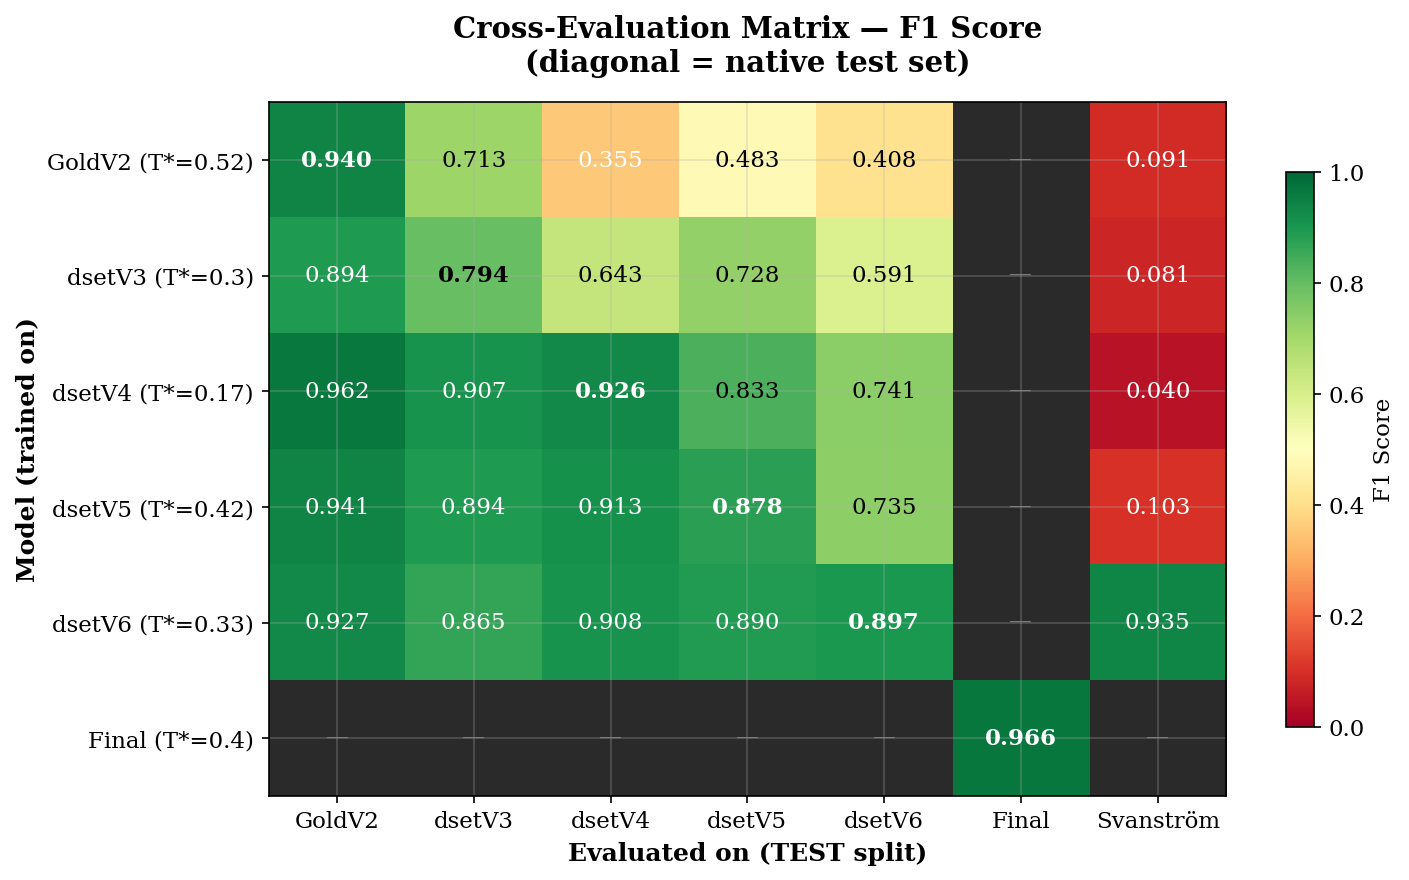

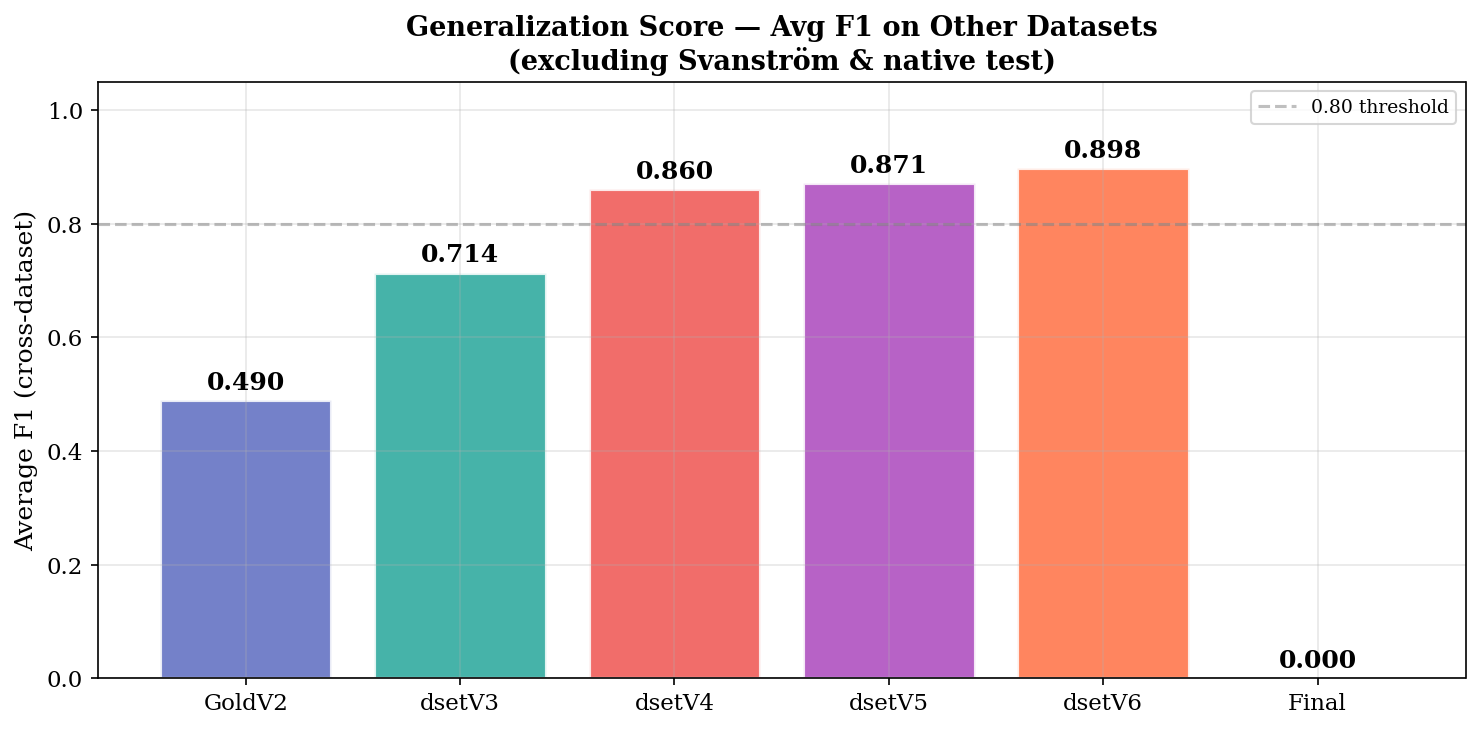

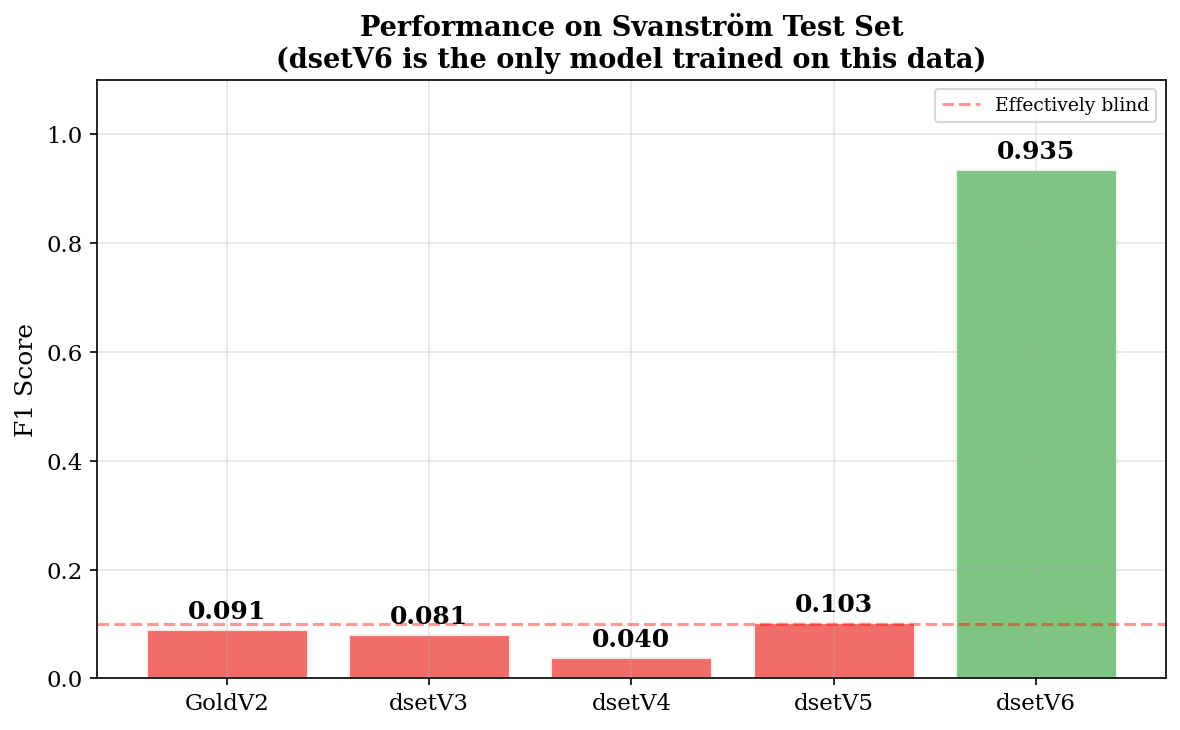


////////////////////////////////////////////////////////////
  PRECISION Matrix
////////////////////////////////////////////////////////////


,GoldV2,dsetV3,dsetV4,dsetV5,dsetV6,Final,Svanström
GoldV2,0.9532,0.8439,0.6355,0.6122,0.5015,—,0.1181
dsetV3,0.9640,0.8967,0.8186,0.8476,0.6639,—,0.0970
dsetV4,0.9572,0.9031,0.9578,0.9057,0.8834,—,0.0328
dsetV5,0.9661,0.9126,0.9507,0.9467,0.7944,—,0.1092
dsetV6,0.9549,0.9073,0.9459,0.9519,0.9445,—,0.9291
Final,—,—,—,—,—,0.9660,—



////////////////////////////////////////////////////////////
  RECALL Matrix
////////////////////////////////////////////////////////////


,GoldV2,dsetV3,dsetV4,dsetV5,dsetV6,Final,Svanström
GoldV2,0.9277,0.6178,0.2465,0.3986,0.3436,—,0.0739
dsetV3,0.8340,0.7121,0.5290,0.6378,0.5332,—,0.0694
dsetV4,0.9660,0.9103,0.8971,0.7702,0.6373,—,0.0514
dsetV5,0.9170,0.8766,0.8781,0.8190,0.6838,—,0.0983
dsetV6,0.9011,0.8262,0.8733,0.8356,0.8545,—,0.9416
Final,—,—,—,—,—,0.9654,—



////////////////////////////////////////////////////////////
  mAP@0.5 Matrix
////////////////////////////////////////////////////////////


,GoldV2,dsetV3,dsetV4,dsetV5,dsetV6,Final,Svanström
GoldV2,0.9621,0.7250,0.2703,0.4434,0.3498,—,0.0321
dsetV3,0.9040,0.7806,0.5590,0.6725,0.5145,—,0.0254
dsetV4,0.9818,0.9423,0.9518,0.8260,0.6988,—,0.0204
dsetV5,0.9541,0.9136,0.9348,0.8751,0.6894,—,0.0322
dsetV6,0.9569,0.9014,0.9298,0.8863,0.8951,—,0.9282
Final,—,—,—,—,—,0.9570,—


In [13]:
# ///////////
# CROSS-EVALUATION MATRIX — Every Model × Every Dataset
# ///////////
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

RUNS_DIR = Path("../runs")

# Model → run directory name (native runs) and cross-eval prefix
MODELS = {
    'GoldV2': {'native': 'IR_FT_goldV2_IRdsetV1_aug0_s0_pilot', 'T': 0.52},
    'dsetV3': {'native': 'IR_FT_dsetV3_aug0_s0', 'T': 0.30},
    'dsetV4': {'native': 'IR_FT_dsetV4_aug0_s0', 'T': 0.17},
    'dsetV5': {'native': 'IR_FT_dsetV5_aug0_s0', 'T': 0.42},
    'dsetV6': {'native': 'IR_FT_dsetV6_aug1_s0', 'T': 0.33},
    'Final': {'native': 'IR_FT_final_cleaned_s0', 'T': 0.40},
}

DATASETS = ['GoldV2', 'dsetV3', 'dsetV4', 'dsetV5', 'dsetV6', 'Final', 'Svanström']

def load_f1_and_metrics(model_name, dataset_name):
    """Load metrics for a model evaluated on a dataset."""
    if model_name == dataset_name:
        # Native eval
        run_dir = RUNS_DIR / MODELS[model_name]['native']
    else:
        # Cross-eval
        run_dir = RUNS_DIR / f"CROSSEVAL_{model_name}_on_{dataset_name}"
    
    mf = run_dir / "metrics.json"
    if not mf.exists():
        return None
    with open(mf) as f:
        data = json.load(f)
    return data.get('test', data.get('dev', {}))

# ── Build the full metrics matrix ──
f1_matrix = pd.DataFrame(index=list(MODELS.keys()), columns=DATASETS, dtype=float)
p_matrix = pd.DataFrame(index=list(MODELS.keys()), columns=DATASETS, dtype=float)
r_matrix = pd.DataFrame(index=list(MODELS.keys()), columns=DATASETS, dtype=float)
mAP_matrix = pd.DataFrame(index=list(MODELS.keys()), columns=DATASETS, dtype=float)

for model in MODELS:
    for dataset in DATASETS:
        metrics = load_f1_and_metrics(model, dataset)
        if metrics:
            f1_matrix.loc[model, dataset] = metrics.get('f1')
            p_matrix.loc[model, dataset] = metrics.get('precision')
            r_matrix.loc[model, dataset] = metrics.get('recall')
            mAP_matrix.loc[model, dataset] = metrics.get('mAP50')

# ///////////
# 1. F1 HEATMAP
# ///////////
fig, ax = plt.subplots(figsize=(10, 6))
data = f1_matrix.astype(float).values
mask = np.isnan(data)

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad(color='#2a2a2a')
norm = mcolors.Normalize(vmin=0, vmax=1)

im = ax.imshow(np.where(mask, np.nan, data), cmap=cmap, norm=norm, aspect='auto')

# Annotate cells
for i in range(len(MODELS)):
    for j in range(len(DATASETS)):
        val = data[i, j]
        if not np.isnan(val):
            color = 'white' if val < 0.4 or val > 0.85 else 'black'
            weight = 'bold' if i == j else 'normal'  # bold for native
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    color=color, fontweight=weight, fontsize=11)
        else:
            ax.text(j, i, '—', ha='center', va='center', color='gray', fontsize=11)

ax.set_xticks(range(len(DATASETS)))
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels([f'{m} (T*={MODELS[m]["T"]})' for m in MODELS], fontsize=11)
ax.set_xlabel('Evaluated on (TEST split)', fontsize=12, fontweight='bold')
ax.set_ylabel('Model (trained on)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Evaluation Matrix — F1 Score\n(diagonal = native test set)', 
             fontsize=14, fontweight='bold', pad=15)

plt.colorbar(im, ax=ax, label='F1 Score', shrink=0.8)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'cross_eval_heatmap.png', dpi=200)
plt.show()

# ///////////
# 2. GENERALIZATION BAR CHART — Average off-diagonal F1
# ///////////
avg_cross = {}
for model in MODELS:
    vals = []
    for dataset in DATASETS:
        if dataset != model and dataset != 'Svanström':
            v = f1_matrix.loc[model, dataset]
            if pd.notna(v):
                vals.append(v)
    avg_cross[model] = np.mean(vals) if vals else 0

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#5C6BC0', '#26A69A', '#EF5350', '#AB47BC', '#FF7043']
bars = ax.bar(avg_cross.keys(), avg_cross.values(), color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, avg_cross.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Average F1 (cross-dataset)', fontsize=12)
ax.set_title('Generalization Score — Avg F1 on Other Datasets\n(excluding Svanström & native test)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.80 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / 'cross_eval_generalization.png', dpi=200)
plt.show()

# ///////////
# 3. SVANSTRÖM COLUMN — False Positive Vulnerability
# ///////////
svan_col = f1_matrix['Svanström'].dropna().astype(float)
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#EF5350' if v < 0.2 else '#FF7043' if v < 0.5 else '#66BB6A' for v in svan_col.values]
bars = ax.bar(svan_col.index, svan_col.values, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, svan_col.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Performance on Svanström Test Set\n(dsetV6 is the only model trained on this data)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.4, label='Effectively blind')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / 'svanstrom_performance.png', dpi=200)
plt.show()

# ///////////
# 4. PRECISION & RECALL TABLES
# ///////////
print('\n' + '/'*60)
print('  PRECISION Matrix')
print('/'*60)
display(p_matrix.style.format('{:.4f}', na_rep='—')
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
        .set_caption('Precision — Cross-Evaluation'))

print('\n' + '/'*60)
print('  RECALL Matrix')
print('/'*60)
display(r_matrix.style.format('{:.4f}', na_rep='—')
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
        .set_caption('Recall — Cross-Evaluation'))

print('\n' + '/'*60)
print('  mAP@0.5 Matrix')
print('/'*60)
display(mAP_matrix.style.format('{:.4f}', na_rep='—')
        .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
        .set_caption('mAP@0.5 — Cross-Evaluation'))
